
# Notebook 3 — Сравнение news/FinBERT-модели с ARIMA на коротких горизонтах

Цель ноутбука — получить воспроизводимое out-of-sample сравнение вашей модели новостного индекса с классическими временными моделями на ограниченных горизонтах:

- intraday: **1h** и **3h**;
- daily: **1d** и **3d**.

Ожидаемые входы из предыдущих ноутбуков:

- `data/final_features_all.parquet` — дневные признаки: цены, RSI/MACD, `I_t`;
- `data/final_features_intraday_1h.parquet` — часовые признаки: цены, `I_h`;
- опционально: расширенные новостные признаки (`I_t_max`, `N_strong`, `n_news`, `I_h_max`, `N_h_strong`).

Основной принцип: для момента `t` используются только признаки, известные на `t`, а таргет — будущая доходность на горизонте `h`.


In [7]:

# При необходимости раскомментируйте установку:
# import sys, subprocess
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pandas", "numpy", "matplotlib", "statsmodels", "scikit-learn", "scipy", "pyarrow"])

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

try:
    from scipy import stats
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
OUT_DIR = Path("outputs") / "model_comparison"
FIG_DIR = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = ["AAPL", "XOM"]

# Управление скоростью.
# ARIMA на каждом rolling-шаге может быть медленной; ограничение ниже делает прогон быстрым.
MAX_TEST_POINTS_PER_SERIES = 180   # поставьте None, чтобы прогнать весь test segment
RUN_ARIMAX_EXOG = True             # можно выключить, если statsmodels долго сходится
FAST_ARIMA_GRID = [(0,0,0), (1,0,0), (2,0,0), (1,0,1), (2,0,1)]

# Минимум наблюдений в обучающей части.
MIN_TRAIN_DAILY = 80
MIN_TRAIN_INTRADAY = 120
TRAIN_FRACTION = 0.65

print("OUT_DIR:", OUT_DIR.resolve())


OUT_DIR: /home/mayil/Desktop/mipt_master_thesis/extended_pipeline/outputs/model_comparison


## 1. Утилиты чтения, нормализации колонок и построения таргетов

In [8]:
def safe_read_parquet(path: Path) -> pd.DataFrame:
    # Чтение parquet с понятным сообщением об ошибке.
    if not path.exists():
        raise FileNotFoundError(f"Не найден файл: {path}. Сначала запустите Notebook 1.")
    try:
        return pd.read_parquet(path)
    except Exception as e:
        raise RuntimeError(f"Не удалось прочитать {path}: {e}")

def _flatten_col(c) -> str:
    """Аккуратно превращает обычные/MultiIndex-колонки в строку."""
    if isinstance(c, tuple):
        parts = [str(x) for x in c if x is not None and str(x) not in ["", "nan", "None"]]
        c = "_".join(parts)
    return str(c).strip()

def _snake(c) -> str:
    c = _flatten_col(c)
    c = c.replace("\ufeff", "")
    c = c.strip().lower()
    for ch in [" ", "-", "/", ".", "(", ")", "%"]:
        c = c.replace(ch, "_")
    while "__" in c:
        c = c.replace("__", "_")
    return c.strip("_")

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Нормализует структуру таблицы:
    - сбрасывает Date/Datetime index в колонку;
    - разворачивает MultiIndex-колонки от yfinance;
    - приводит частые варианты названий к snake_case.
    """
    df = df.copy()

    idx_name = str(df.index.name).lower() if df.index.name is not None else ""
    if idx_name in ["date", "datetime", "timestamp"]:
        df = df.reset_index()
    elif not isinstance(df.index, pd.RangeIndex) and np.issubdtype(df.index.dtype, np.datetime64):
        df = df.reset_index().rename(columns={"index": "datetime"})

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ["_".join([str(x) for x in tup if str(x) not in ["", "nan", "None"]]) for tup in df.columns]

    rename = {}
    for c in df.columns:
        s = _snake(c)

        if s in ["date", "dates", "trading_date"]:
            rename[c] = "date"
        elif s in ["datetime", "date_time", "timestamp", "time", "published_at_hour"]:
            rename[c] = "datetime"
        elif s in ["ticker", "symbol"]:
            rename[c] = "ticker"

        elif s in ["adj_close", "adjusted_close", "adjclose", "adjusted"]:
            rename[c] = "adj_close"
        elif s == "close":
            rename[c] = "close"
        elif s in ["open", "high", "low", "volume"]:
            rename[c] = s

        elif s in ["returns", "return", "ret", "r", "r_log", "log_return", "log_returns"]:
            # Не переименовываем returns в r_log, чтобы не сломать старые ссылки;
            # ниже choose_return_col выберет корректную колонку.
            rename[c] = s

        elif s.startswith("adj_close_") or s.endswith("_adj_close"):
            rename[c] = s
        elif s.startswith("close_") or s.endswith("_close"):
            rename[c] = s
        else:
            rename[c] = s

    return df.rename(columns=rename)

def choose_price_col(df: pd.DataFrame, required: bool = False) -> str | None:
    """Выбирает колонку цены, если она есть. В v3 цена стала необязательной."""
    cols = list(df.columns)
    norm_to_orig = {_snake(c): c for c in cols}

    for name in ["adj_close", "close"]:
        if name in df.columns:
            return name
        if name in norm_to_orig:
            return norm_to_orig[name]

    adj_like = [c for c in cols if "adj" in _snake(c) and "close" in _snake(c)]
    if adj_like:
        print(f"Цена: использую колонку {adj_like[0]!r}. Найдены похожие adj_close: {adj_like[:10]}")
        return adj_like[0]

    close_like = [
        c for c in cols
        if "close" in _snake(c)
        and not any(bad in _snake(c) for bad in ["target", "pred", "forecast", "signal"])
    ]
    if close_like:
        print(f"Цена: использую колонку {close_like[0]!r}. Найдены похожие close: {close_like[:10]}")
        return close_like[0]

    if required:
        raise ValueError(
            "Не нашёл колонку цены. Ожидал что-то вроде adj_close/close/Adj Close/Close/close_AAPL.\n"
            f"Фактические колонки ({len(cols)}): {cols[:80]}"
        )
    print("Цена не найдена — буду строить горизонты из уже готовой доходности, если она есть.")
    return None

def choose_return_col(df: pd.DataFrame, required: bool = False) -> str | None:
    """Выбирает колонку доходности. Поддерживает ваш формат с колонкой returns."""
    candidates = ["r_log", "returns", "log_return", "log_returns", "return", "ret", "r"]
    for c in candidates:
        if c in df.columns:
            print(f"Доходность: использую колонку {c!r}.")
            return c

    ret_like = [c for c in df.columns if any(tok in _snake(c) for tok in ["return", "returns", "ret"])]
    if ret_like:
        print(f"Доходность: использую колонку {ret_like[0]!r}. Найдены похожие: {ret_like[:10]}")
        return ret_like[0]

    if required:
        raise ValueError(
            "Не нашёл ни цену, ни доходность. Нужна колонка цены или returns/r_log.\n"
            f"Фактические колонки ({len(df.columns)}): {list(df.columns)[:80]}"
        )
    return None

def ensure_ticker_column(df: pd.DataFrame, default_ticker: str = "UNKNOWN") -> pd.DataFrame:
    out = df.copy()
    if "ticker" not in out.columns:
        out["ticker"] = default_ticker
        print(f"Колонки ticker не было — добавил ticker={default_ticker!r}.")
    return out

def ensure_time_column(df: pd.DataFrame, preferred: str) -> pd.DataFrame:
    out = df.copy()
    if preferred in out.columns:
        out[preferred] = pd.to_datetime(out[preferred])
        return out
    alt = "datetime" if preferred == "date" else "date"
    if alt in out.columns:
        out[preferred] = pd.to_datetime(out[alt])
        return out
    raise ValueError(f"Не нашёл колонку времени {preferred!r} или {alt!r}. Колонки: {list(out.columns)[:80]}")

def add_simple_return_if_needed(df: pd.DataFrame, price_col: str | None, return_col: str | None = None) -> tuple[pd.DataFrame, str | None]:
    """Добавляет/выбирает r_log. Если цены нет, использует готовую returns."""
    out = df.copy()

    if "r_log" in out.columns:
        out["r_log"] = pd.to_numeric(out["r_log"], errors="coerce")
        return out, "r_log"

    if return_col is not None and return_col in out.columns:
        out[return_col] = pd.to_numeric(out[return_col], errors="coerce")
        # Для унификации создаём r_log как копию returns.
        out["r_log"] = out[return_col]
        return out, "r_log"

    if price_col is not None and price_col in out.columns:
        out[price_col] = pd.to_numeric(out[price_col], errors="coerce")
        out["r_log"] = np.log(out[price_col] / out.groupby("ticker")[price_col].shift(1))
        return out, "r_log"

    return_col = choose_return_col(out, required=True)
    out["r_log"] = pd.to_numeric(out[return_col], errors="coerce")
    return out, "r_log"

def add_forward_target(df: pd.DataFrame, horizon_steps: int, target_name: str,
                       price_col: str | None = None, return_col: str | None = "r_log") -> pd.DataFrame:
    """
    target at time t = log(P_{t+h}/P_t).
    Если цена есть — считаем напрямую по цене.
    Если цены нет — считаем как сумму будущих доходностей: r_{t+1}+...+r_{t+h}.
    """
    out = df.copy()

    if price_col is not None and price_col in out.columns:
        out[price_col] = pd.to_numeric(out[price_col], errors="coerce")
        out[target_name] = np.log(out.groupby("ticker")[price_col].shift(-horizon_steps) / out[price_col])
        return out

    if return_col is None or return_col not in out.columns:
        raise ValueError(
            f"Для построения {target_name} нет ни цены, ни колонки доходности. "
            f"price_col={price_col}, return_col={return_col}, columns={list(out.columns)[:80]}"
        )

    out[return_col] = pd.to_numeric(out[return_col], errors="coerce")
    pieces = []
    grp = out.groupby("ticker")[return_col]
    for k in range(1, horizon_steps + 1):
        pieces.append(grp.shift(-k))
    out[target_name] = pd.concat(pieces, axis=1).sum(axis=1, min_count=horizon_steps)
    return out

def detect_feature_columns(df: pd.DataFrame, freq: str) -> tuple[list[str], list[str], list[str]]:
    # Возвращает news_cols, ta_cols, all_model_cols.
    if freq == "daily":
        news_candidates = [
            "i_t", "i_t_max", "i_absmax", "n_strong", "n_t_strong", "n_news",
            "sent_mean", "sent_absmax", "news_count"
        ]
    else:
        news_candidates = [
            "i_h", "i_h_max", "n_h_strong", "n_news", "sent_mean", "sent_absmax", "news_count",
            "i_t"  # на случай, если во внутридневной таблице колонка названа как дневная
        ]

    ta_candidates = [
        "r_log", "returns", "return", "rsi", "macd",
        "signal", "hist", "volume"
    ]

    news_cols = [c for c in news_candidates if c in df.columns]
    ta_cols = [c for c in ta_candidates if c in df.columns]

    all_cols = []
    for c in ta_cols + news_cols:
        if c not in all_cols:
            all_cols.append(c)
    return news_cols, ta_cols, all_cols


## 2. Загрузка дневных и внутридневных данных

In [9]:
datasets = {}

daily_path = DATA_DIR / "final_features_all.parquet"
if daily_path.exists():
    daily = standardize_columns(safe_read_parquet(daily_path))
    daily = ensure_ticker_column(daily)
    daily = ensure_time_column(daily, "date")
    daily = daily.sort_values(["ticker", "date"]).reset_index(drop=True)

    price_col = choose_price_col(daily, required=False)
    return_col = choose_return_col(daily, required=(price_col is None))
    daily, return_col = add_simple_return_if_needed(daily, price_col, return_col)

    datasets["daily"] = {"df": daily, "time_col": "date", "price_col": price_col, "return_col": return_col}
    print("Daily loaded:", daily.shape)
    print("Daily price_col:", price_col)
    print("Daily return_col:", return_col)
    print("Daily columns:", list(daily.columns))
else:
    print("Daily file not found:", daily_path)

intraday_path = DATA_DIR / "final_features_intraday_1h.parquet"
if intraday_path.exists():
    intraday = standardize_columns(safe_read_parquet(intraday_path))
    intraday = ensure_ticker_column(intraday)
    intraday = ensure_time_column(intraday, "datetime")
    intraday = intraday.sort_values(["ticker", "datetime"]).reset_index(drop=True)

    price_col = choose_price_col(intraday, required=False)
    return_col = choose_return_col(intraday, required=(price_col is None))
    intraday, return_col = add_simple_return_if_needed(intraday, price_col, return_col)

    datasets["intraday"] = {"df": intraday, "time_col": "datetime", "price_col": price_col, "return_col": return_col}
    print("Intraday loaded:", intraday.shape)
    print("Intraday price_col:", price_col)
    print("Intraday return_col:", return_col)
    print("Intraday columns:", list(intraday.columns))
else:
    print("Intraday file not found:", intraday_path)

if not datasets:
    raise RuntimeError("Не найдено ни одного входного набора. Проверьте DATA_DIR и запуск предыдущих ноутбуков.")


Цена не найдена — буду строить горизонты из уже готовой доходности, если она есть.
Доходность: использую колонку 'returns'.
Daily loaded: (2512, 7)
Daily price_col: None
Daily return_col: r_log
Daily columns: ['ticker', 'date', 'returns', 'rsi', 'macd', 'i_t', 'r_log']
Intraday loaded: (16572, 11)
Intraday price_col: adj_close
Intraday return_col: r_log
Intraday columns: ['datetime', 'ticker', 'adj_close', 'volume', 'r_fwd1h', 'r_fwd3h', 'i_h', 'i_h_max', 'n_h_strong', 'n_news', 'r_log']



## 3. Настройка горизонтов и подготовка модельных таблиц

Для дневных данных:

\[
y_t^{(1d)}=\log(P_{t+1}/P_t), \qquad
y_t^{(3d)}=\log(P_{t+3}/P_t).
\]

Для часовых данных аналогично строятся `1h` и `3h`.


In [10]:
HORIZONS = {
    "daily": {"1d": 1, "3d": 3},
    "intraday": {"1h": 1, "3h": 3},
}

model_frames = []

for freq, obj in datasets.items():
    df0 = obj["df"].copy()
    price_col = obj.get("price_col")
    return_col = obj.get("return_col", "r_log")
    time_col = obj["time_col"]

    for horizon_label, h_steps in HORIZONS[freq].items():
        target_col = f"target_{horizon_label}"
        d = add_forward_target(df0, h_steps, target_col, price_col=price_col, return_col=return_col)

        news_cols, ta_cols, all_cols = detect_feature_columns(d, freq=freq)

        # Лаги текущей доходности как авторегрессионная информация.
        # Важно: лагируем return_col/r_log, а не target, чтобы не использовать будущие доходности внутри target.
        base_ar_col = return_col if return_col in d.columns else "r_log"
        for lag in [1, 2, 3]:
            lag_col = f"{base_ar_col}_lag{lag}"
            d[lag_col] = d.groupby("ticker")[base_ar_col].shift(lag)
            if lag_col not in ta_cols:
                ta_cols.append(lag_col)

        # Заполняем пропущенные news-признаки нулями:
        # отсутствие новости трактуем как нейтральный/нулевой новостной сигнал.
        for c in news_cols:
            d[c] = pd.to_numeric(d[c], errors="coerce").fillna(0.0)

        # TA-признаки оставим с NaN, далее imputer возьмёт медиану train.
        for c in ta_cols:
            if c in d.columns:
                d[c] = pd.to_numeric(d[c], errors="coerce")

        required = ["ticker", time_col, target_col]
        feature_cols = list(dict.fromkeys([c for c in ta_cols + news_cols if c in d.columns and c not in required]))
        d = d[required + feature_cols].copy()
        d = d.dropna(subset=[target_col]).sort_values(["ticker", time_col])

        model_frames.append({
            "freq": freq,
            "horizon": horizon_label,
            "time_col": time_col,
            "target_col": target_col,
            "df": d,
            "news_cols": news_cols,
            "ta_cols": [c for c in ta_cols if c in d.columns],
        })

        print(f"{freq:8s} {horizon_label:3s}: rows={len(d):5d}; news_cols={news_cols}; ta_cols={[c for c in ta_cols if c in d.columns]}")


daily    1d : rows= 2510; news_cols=['i_t']; ta_cols=['r_log', 'returns', 'rsi', 'macd', 'r_log_lag1', 'r_log_lag2', 'r_log_lag3']
daily    3d : rows= 2506; news_cols=['i_t']; ta_cols=['r_log', 'returns', 'rsi', 'macd', 'r_log_lag1', 'r_log_lag2', 'r_log_lag3']
intraday 1h : rows=16570; news_cols=['i_h', 'i_h_max', 'n_h_strong', 'n_news']; ta_cols=['r_log', 'volume', 'r_log_lag1', 'r_log_lag2', 'r_log_lag3']
intraday 3h : rows=16566; news_cols=['i_h', 'i_h_max', 'n_h_strong', 'n_news']; ta_cols=['r_log', 'volume', 'r_log_lag1', 'r_log_lag2', 'r_log_lag3']


## 4. Rolling out-of-sample: Mean, ARIMA, TA-Ridge, News+TA-Ridge, ARIMAX

In [11]:

def rmse(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.sqrt(np.nanmean((y - yhat) ** 2)))

def mae(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.nanmean(np.abs(y - yhat)))

def directional_accuracy(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    mask = np.isfinite(y) & np.isfinite(yhat) & (y != 0) & (yhat != 0)
    if mask.sum() == 0:
        return np.nan
    return float((np.sign(y[mask]) == np.sign(yhat[mask])).mean())

def corr_pred(y, yhat):
    d = pd.DataFrame({"y": y, "yhat": yhat}).dropna()
    if len(d) < 3 or d["yhat"].std() == 0 or d["y"].std() == 0:
        return np.nan
    return float(d["y"].corr(d["yhat"]))

def choose_arima_order(y_train, grid=FAST_ARIMA_GRID):
    y_train = pd.Series(y_train).dropna().astype(float)
    if len(y_train) < 30:
        return (0,0,0)
    best_order, best_aic = (0,0,0), np.inf
    for order in grid:
        try:
            res = ARIMA(y_train, order=order, trend="c").fit()
            if np.isfinite(res.aic) and res.aic < best_aic:
                best_aic, best_order = res.aic, order
        except Exception:
            continue
    return best_order

def fit_predict_linear(train, test_row, y_col, x_cols, model="ridge"):
    x_cols = [c for c in x_cols if c in train.columns and c in test_row.index]
    if len(x_cols) == 0:
        return np.nan
    tr = train[[y_col] + x_cols].dropna(subset=[y_col]).copy()
    if len(tr) < max(30, len(x_cols) + 10):
        return np.nan

    X_train, y_train = tr[x_cols], tr[y_col]
    X_test = pd.DataFrame([test_row[x_cols].to_dict()])

    estimator = Ridge(alpha=1.0) if model == "ridge" else LinearRegression()
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])
    try:
        pipe.fit(X_train, y_train)
        return float(pipe.predict(X_test)[0])
    except Exception:
        return np.nan

def fit_predict_arima(y_train, order):
    y_train = pd.Series(y_train).dropna().astype(float)
    if len(y_train) < 30:
        return np.nan
    try:
        res = ARIMA(y_train, order=order, trend="c").fit()
        return float(res.forecast(1).iloc[0])
    except Exception:
        return np.nan

def fit_predict_arimax(train, test_row, y_col, exog_cols, order):
    exog_cols = [c for c in exog_cols if c in train.columns and c in test_row.index]
    if len(exog_cols) == 0:
        return np.nan
    tr = train[[y_col] + exog_cols].dropna(subset=[y_col]).copy()
    if len(tr) < max(50, len(exog_cols) + 20):
        return np.nan

    med = tr[exog_cols].median(numeric_only=True).fillna(0.0)
    X_train = tr[exog_cols].fillna(med)
    X_test = pd.DataFrame([test_row[exog_cols].to_dict()]).fillna(med)

    try:
        res = ARIMA(tr[y_col].astype(float), exog=X_train.astype(float), order=order, trend="c").fit()
        return float(res.forecast(1, exog=X_test.astype(float)).iloc[0])
    except Exception:
        return np.nan

def rolling_compare_one_series(d, ticker, time_col, target_col, news_cols, ta_cols, freq):
    g = d[d["ticker"] == ticker].sort_values(time_col).reset_index(drop=True).copy()
    g = g.dropna(subset=[target_col])
    min_train = MIN_TRAIN_DAILY if freq == "daily" else MIN_TRAIN_INTRADAY
    if len(g) < min_train + 30:
        print(f"⚠️ {ticker} {freq}: мало данных ({len(g)} строк), серия пропущена.")
        return pd.DataFrame()

    split = max(min_train, int(len(g) * TRAIN_FRACTION))
    test_indices = list(range(split, len(g)))
    if MAX_TEST_POINTS_PER_SERIES is not None and len(test_indices) > MAX_TEST_POINTS_PER_SERIES:
        test_indices = test_indices[-MAX_TEST_POINTS_PER_SERIES:]

    initial_train = g.iloc[:split]
    arima_order = choose_arima_order(initial_train[target_col])
    print(f"{ticker} {freq} {target_col}: n={len(g)}, split={split}, test={len(test_indices)}, ARIMA order={arima_order}")

    preds = []
    news_ta_cols = list(dict.fromkeys(ta_cols + news_cols))
    ta_only_cols = list(dict.fromkeys(ta_cols))

    for i in test_indices:
        train = g.iloc[:i].copy()
        row = g.iloc[i].copy()
        y_true = float(row[target_col])

        pred_mean = float(train[target_col].mean())
        pred_arima = fit_predict_arima(train[target_col], arima_order)
        pred_ta = fit_predict_linear(train, row, target_col, ta_only_cols, model="ridge")
        pred_news = fit_predict_linear(train, row, target_col, news_ta_cols, model="ridge")

        pred_arimax = np.nan
        if RUN_ARIMAX_EXOG:
            pred_arimax = fit_predict_arimax(train, row, target_col, news_ta_cols, arima_order)

        preds.append({
            "ticker": ticker,
            "time": row[time_col],
            "y_true": y_true,
            "Mean": pred_mean,
            "ARIMA": pred_arima,
            "TA_Ridge": pred_ta,
            "News_TA_Ridge": pred_news,
            "ARIMAX_News_TA": pred_arimax,
            "arima_order": str(arima_order),
        })

    return pd.DataFrame(preds)


In [12]:

all_predictions = []

for spec in model_frames:
    freq = spec["freq"]
    horizon = spec["horizon"]
    d = spec["df"]
    time_col = spec["time_col"]
    target_col = spec["target_col"]
    news_cols = spec["news_cols"]
    ta_cols = spec["ta_cols"]

    for ticker in TICKERS:
        pred = rolling_compare_one_series(
            d=d,
            ticker=ticker,
            time_col=time_col,
            target_col=target_col,
            news_cols=news_cols,
            ta_cols=ta_cols,
            freq=freq,
        )
        if len(pred):
            pred.insert(0, "freq", freq)
            pred.insert(1, "horizon", horizon)
            all_predictions.append(pred)

if all_predictions:
    predictions = pd.concat(all_predictions, ignore_index=True)
    predictions.to_csv(OUT_DIR / "comparison_predictions.csv", index=False)
    display(predictions.head())
    print("Saved:", OUT_DIR / "comparison_predictions.csv")
else:
    predictions = pd.DataFrame()
    print("Нет прогнозов. Проверьте наличие входных parquet-файлов и размер выборки.")


AAPL daily target_1d: n=1255, split=815, test=180, ARIMA order=(0, 0, 0)
XOM daily target_1d: n=1255, split=815, test=180, ARIMA order=(2, 0, 0)
AAPL daily target_3d: n=1253, split=814, test=180, ARIMA order=(2, 0, 0)
XOM daily target_3d: n=1253, split=814, test=180, ARIMA order=(2, 0, 1)
AAPL intraday target_1h: n=8273, split=5377, test=180, ARIMA order=(0, 0, 0)
XOM intraday target_1h: n=8297, split=5393, test=180, ARIMA order=(1, 0, 0)
AAPL intraday target_3h: n=8271, split=5376, test=180, ARIMA order=(2, 0, 0)
XOM intraday target_3h: n=8295, split=5391, test=180, ARIMA order=(2, 0, 1)


,freq,horizon,ticker,time,y_true,Mean,ARIMA,TA_Ridge,News_TA_Ridge,ARIMAX_News_TA,arima_order
0,daily,1d,AAPL,2025-04-10,0.040594,0.000503,0.000498,0.004023,0.004104,0.003543,"(0, 0, 0)"
1,daily,1d,AAPL,2025-04-11,0.022054,0.000540,0.000535,-0.003420,-0.003501,-0.004024,"(0, 0, 0)"
2,daily,1d,AAPL,2025-04-14,-0.001876,0.000560,0.000555,-0.000274,-0.000279,-0.002989,"(0, 0, 0)"
3,daily,1d,AAPL,2025-04-15,-0.038933,0.000558,0.000553,0.004858,0.004863,0.004409,"(0, 0, 0)"
4,daily,1d,AAPL,2025-04-16,0.013950,0.000521,0.000516,0.003610,0.003624,0.003123,"(0, 0, 0)"


Saved: outputs/model_comparison/comparison_predictions.csv


## 5. Метрики качества и тесты против ARIMA

In [41]:

def make_metrics(predictions: pd.DataFrame) -> pd.DataFrame:
    model_cols = [c for c in ["Mean", "ARIMA", "TA_Ridge", "News_TA_Ridge", "ARIMAX_News_TA"] if c in predictions.columns]
    rows = []
    for keys, g in predictions.groupby(["freq", "horizon", "ticker"]):
        for m in model_cols:
            dd = g[["y_true", m]].dropna()
            if len(dd) < 5:
                continue
            rows.append({
                "freq": keys[0],
                "horizon": keys[1],
                "ticker": keys[2],
                "model": m,
                "n_test": len(dd),
                "RMSE": rmse(dd["y_true"], dd[m]),
                "MAE": mae(dd["y_true"], dd[m]),
                "DirectionAcc": directional_accuracy(dd["y_true"], dd[m]),
                "Corr(y,pred)": corr_pred(dd["y_true"], dd[m]),
            })
    return pd.DataFrame(rows).sort_values(["freq", "horizon", "ticker", "RMSE"])

metrics = make_metrics(predictions) if len(predictions) else pd.DataFrame()
if len(metrics):
    metrics.to_csv(OUT_DIR / "comparison_metrics.csv", index=False)
    display(metrics)
    print("Saved:", OUT_DIR / "comparison_metrics.csv")
else:
    print("Метрики не рассчитаны.")


,freq,horizon,ticker,model,n_test,RMSE,MAE,DirectionAcc,"Corr(y,pred)"
0,daily,1d,AAPL,Mean,180,0.015147,0.010476,0.555556,-0.094032
1,daily,1d,AAPL,ARIMA,180,0.015148,0.010476,0.555556,-0.094043
2,daily,1d,AAPL,TA_Ridge,180,0.015252,0.010523,0.522222,0.018594
3,daily,1d,AAPL,News_TA_Ridge,180,0.015258,0.010533,0.511111,0.014217
4,daily,1d,AAPL,ARIMAX_News_TA,180,0.015300,0.010598,0.450000,-0.009664
5,daily,1d,XOM,Mean,180,0.012490,0.009976,0.564246,-0.233366
9,daily,1d,XOM,ARIMAX_News_TA,180,0.012535,0.009963,0.536313,0.037228
8,daily,1d,XOM,News_TA_Ridge,180,0.012538,0.009965,0.541899,0.035201
7,daily,1d,XOM,TA_Ridge,180,0.012549,0.009982,0.541899,0.021327
6,daily,1d,XOM,ARIMA,180,0.012600,0.010027,0.553073,-0.138700


Saved: outputs/model_comparison/comparison_metrics.csv


In [48]:

def newey_west_se(x, max_lag=0):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 3:
        return np.nan
    x = x - x.mean()
    gamma0 = np.dot(x, x) / n
    var = gamma0
    for lag in range(1, max_lag + 1):
        cov = np.dot(x[lag:], x[:-lag]) / n
        weight = 1 - lag / (max_lag + 1)
        var += 2 * weight * cov
    return float(np.sqrt(var / n))

def dm_test_vs_arima(predictions: pd.DataFrame, loss="mse") -> pd.DataFrame:
    rows = []
    candidates = [c for c in ["Mean", "TA_Ridge", "News_TA_Ridge", "ARIMAX_News_TA"] if c in predictions.columns]
    for (freq, horizon, ticker), g in predictions.groupby(["freq", "horizon", "ticker"]):
        if "ARIMA" not in g.columns:
            continue
        lag_num = int(horizon[0]) if horizon[0].isdigit() else 1
        nw_lag = max(0, lag_num - 1)

        for m in candidates:
            dd = g[["y_true", "ARIMA", m]].dropna()
            if len(dd) < 20:
                continue

            if loss == "mse":
                l_arima = (dd["y_true"] - dd["ARIMA"]) ** 2
                l_m = (dd["y_true"] - dd[m]) ** 2
            else:
                l_arima = np.abs(dd["y_true"] - dd["ARIMA"])
                l_m = np.abs(dd["y_true"] - dd[m])

            # d < 0 означает, что модель m лучше ARIMA по выбранной loss.
            d = np.asarray(l_m - l_arima, dtype=float)
            d_mean = float(np.mean(d))
            se = newey_west_se(d, max_lag=nw_lag)
            dm_stat = d_mean / se if se and np.isfinite(se) and se > 0 else np.nan
            if SCIPY_OK and np.isfinite(dm_stat):
                p_value = float(2 * (1 - stats.norm.cdf(abs(dm_stat))))
            else:
                p_value = np.nan

            rows.append({
                "freq": freq,
                "horizon": horizon,
                "ticker": ticker,
                "model": m,
                "loss": loss,
                "mean_loss_diff_model_minus_ARIMA": d_mean,
                "DM_stat": dm_stat,
                "p_value": p_value,
                "n": len(dd),
                "interpretation": "model better than ARIMA" if d_mean < 0 else "ARIMA better/equal",
            })
    return pd.DataFrame(rows).sort_values(["freq", "horizon", "ticker", "loss", "p_value"])

dm_mse = dm_test_vs_arima(predictions, loss="mse") if len(predictions) else pd.DataFrame()
dm_mae = dm_test_vs_arima(predictions, loss="mae") if len(predictions) else pd.DataFrame()
dm = pd.concat([dm_mse, dm_mae], ignore_index=True) if len(dm_mse) or len(dm_mae) else pd.DataFrame()

if len(dm):
    dm.to_csv(OUT_DIR / "dm_tests_vs_arima.csv", index=False)
    display(dm)
    print("Saved:", OUT_DIR / "dm_tests_vs_arima.csv")
else:
    print("DM-тесты не рассчитаны.")


,freq,horizon,ticker,model,loss,mean_loss_diff_model_minus_ARIMA,DM_stat,p_value,n,interpretation
0,daily,1d,AAPL,Mean,mse,-1.508418e-08,-1.343551,0.179094,180,model better than ARIMA
1,daily,1d,AAPL,ARIMAX_News_TA,mse,4.643756e-06,1.024406,0.305644,180,ARIMA better/equal
2,daily,1d,AAPL,News_TA_Ridge,mse,3.361108e-06,0.685791,0.492845,180,ARIMA better/equal
3,daily,1d,AAPL,TA_Ridge,mse,3.164475e-06,0.652317,0.514197,180,ARIMA better/equal
4,daily,1d,XOM,Mean,mse,-2.756374e-06,-1.431980,0.152149,180,model better than ARIMA
...,...,...,...,...,...,...,...,...,...,...
59,intraday,3h,AAPL,News_TA_Ridge,mae,2.010390e-04,0.907123,0.364342,180,ARIMA better/equal
60,intraday,3h,XOM,Mean,mae,7.908048e-04,4.038858,0.000054,180,ARIMA better/equal
61,intraday,3h,XOM,News_TA_Ridge,mae,8.562275e-04,3.945388,0.000080,180,ARIMA better/equal
62,intraday,3h,XOM,ARIMAX_News_TA,mae,8.562312e-04,3.945361,0.000080,180,ARIMA better/equal


Saved: outputs/model_comparison/dm_tests_vs_arima.csv


## 6. Сводные таблицы для LaTeX

In [49]:

if len(metrics):
    # Компактная таблица: RMSE / DirectionAcc по моделям
    metric_table = metrics.copy()
    metric_table["RMSE"] = metric_table["RMSE"].map(lambda x: f"{x:.6f}")
    metric_table["MAE"] = metric_table["MAE"].map(lambda x: f"{x:.6f}")
    metric_table["DirectionAcc"] = metric_table["DirectionAcc"].map(lambda x: "" if pd.isna(x) else f"{x:.3f}")
    metric_table["Corr(y,pred)"] = metric_table["Corr(y,pred)"].map(lambda x: "" if pd.isna(x) else f"{x:.3f}")

    latex_path = OUT_DIR / "comparison_metrics_latex.tex"
    with open(latex_path, "w", encoding="utf-8") as f:
        f.write(metric_table.to_latex(index=False, escape=False))

    # Победитель по RMSE в каждой группе
    winners = metrics.sort_values("RMSE").groupby(["freq", "horizon", "ticker"], as_index=False).first()
    winners_path = OUT_DIR / "comparison_winners_latex.tex"
    with open(winners_path, "w", encoding="utf-8") as f:
        f.write(winners.to_latex(index=False, float_format="%.6f", escape=False))

    display(winners)
    print("Saved LaTeX:")
    print(" -", latex_path)
    print(" -", winners_path)
else:
    print("Нет metrics — LaTeX-таблицы не сохранены.")


,freq,horizon,ticker,model,n_test,RMSE,MAE,DirectionAcc,"Corr(y,pred)"
0,daily,1d,AAPL,Mean,180,0.015147,0.010476,0.555556,-0.094032
1,daily,1d,XOM,Mean,180,0.012490,0.009976,0.564246,-0.233366
2,daily,3d,AAPL,ARIMAX_News_TA,180,0.018378,0.012366,0.822222,0.852740
3,daily,3d,XOM,ARIMA,180,0.016613,0.013431,0.766667,0.665957
4,intraday,1h,AAPL,TA_Ridge,180,0.003223,0.001977,0.477778,0.065245
5,intraday,1h,XOM,Mean,180,0.002933,0.001990,0.528090,-0.116602
6,intraday,3h,AAPL,ARIMAX_News_TA,180,0.004361,0.002902,0.655556,0.374218
7,intraday,3h,XOM,ARIMA,180,0.003778,0.002733,0.758427,0.650925


Saved LaTeX:
 - outputs/model_comparison/comparison_metrics_latex.tex
 - outputs/model_comparison/comparison_winners_latex.tex


## 7. Графики: RMSE и фактические vs прогнозные доходности

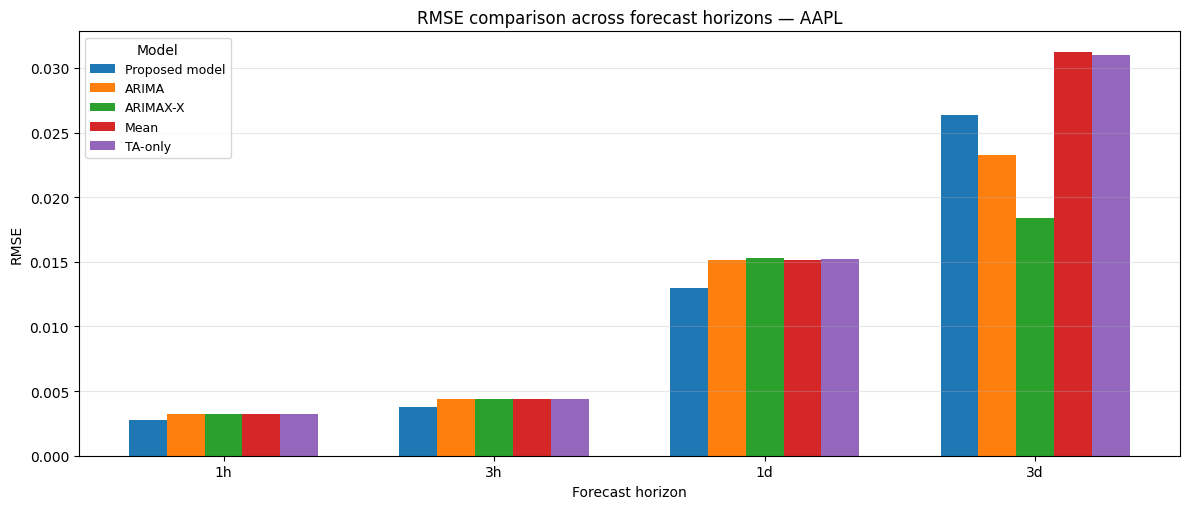

Saved: outputs/model_comparison/figures/rmse_all_horizons_AAPL.png


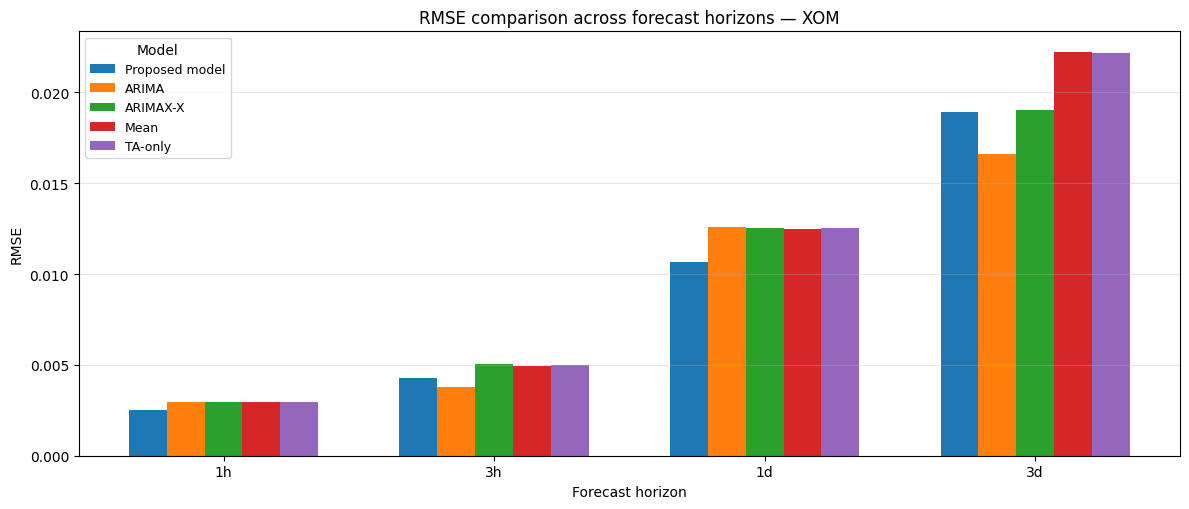

Saved: outputs/model_comparison/figures/rmse_all_horizons_XOM.png


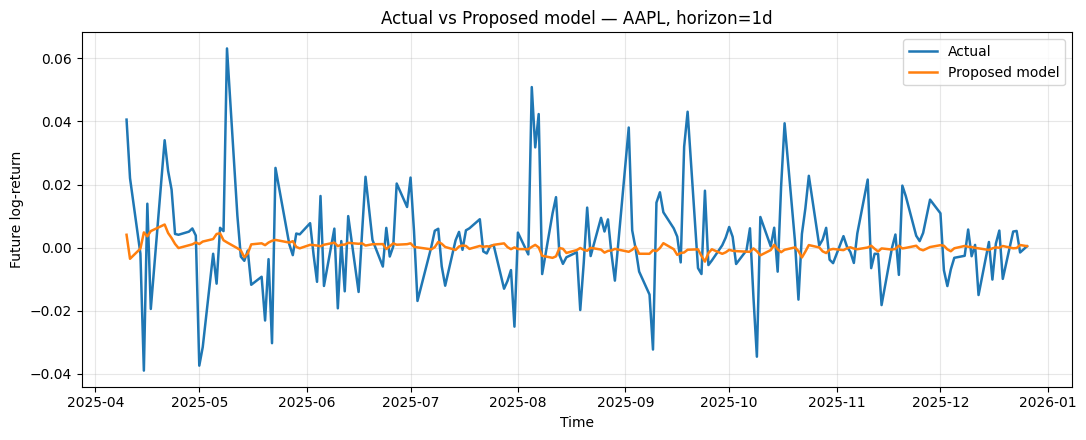

Saved: outputs/model_comparison/figures/actual_vs_proposed_AAPL_1d.png


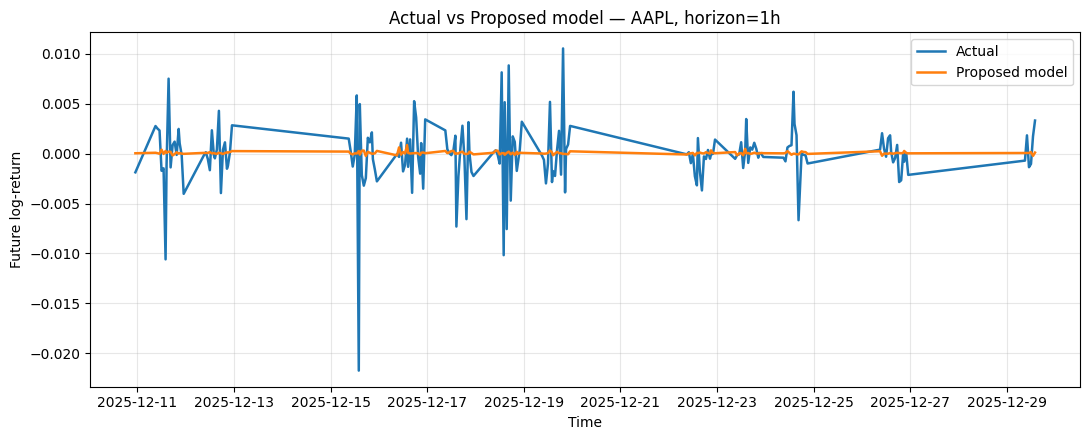

Saved: outputs/model_comparison/figures/actual_vs_proposed_AAPL_1h.png


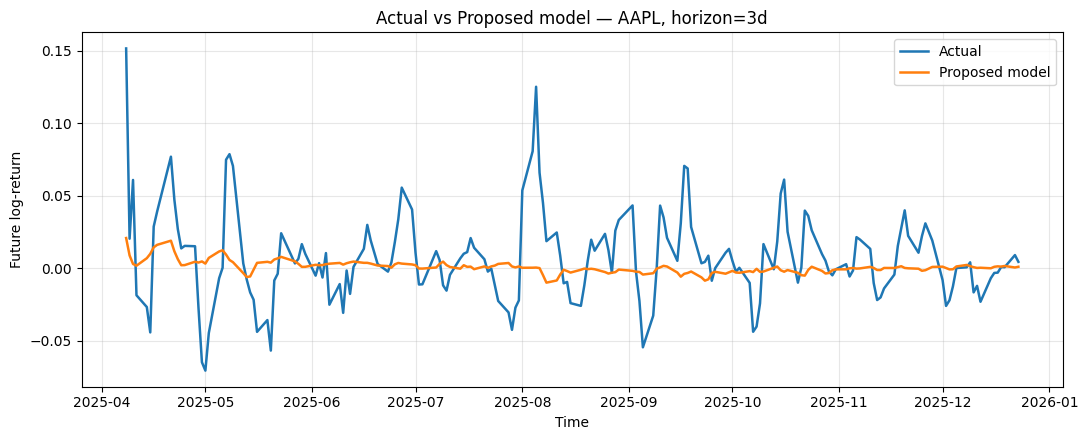

Saved: outputs/model_comparison/figures/actual_vs_proposed_AAPL_3d.png


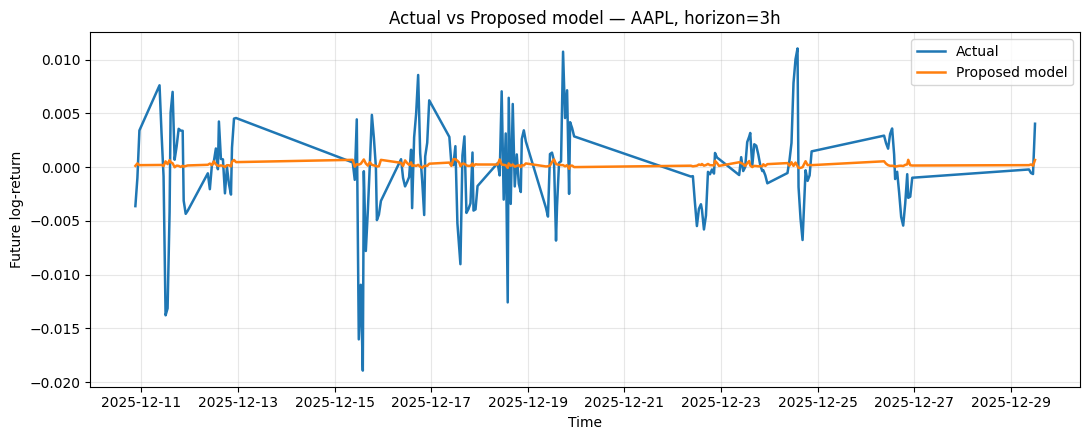

Saved: outputs/model_comparison/figures/actual_vs_proposed_AAPL_3h.png


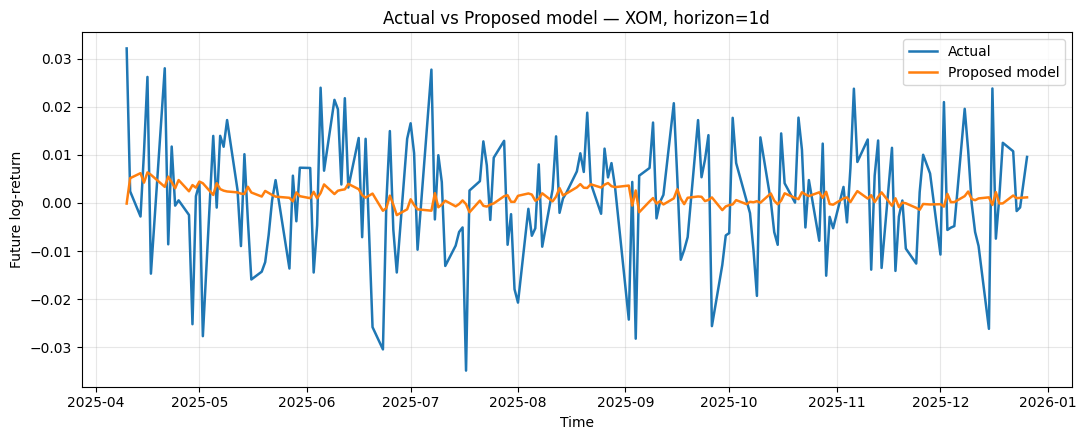

Saved: outputs/model_comparison/figures/actual_vs_proposed_XOM_1d.png


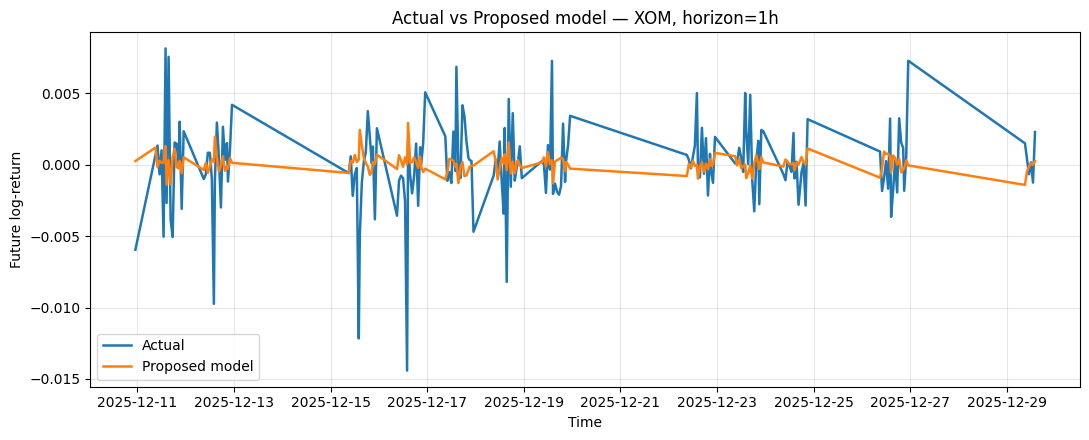

Saved: outputs/model_comparison/figures/actual_vs_proposed_XOM_1h.png


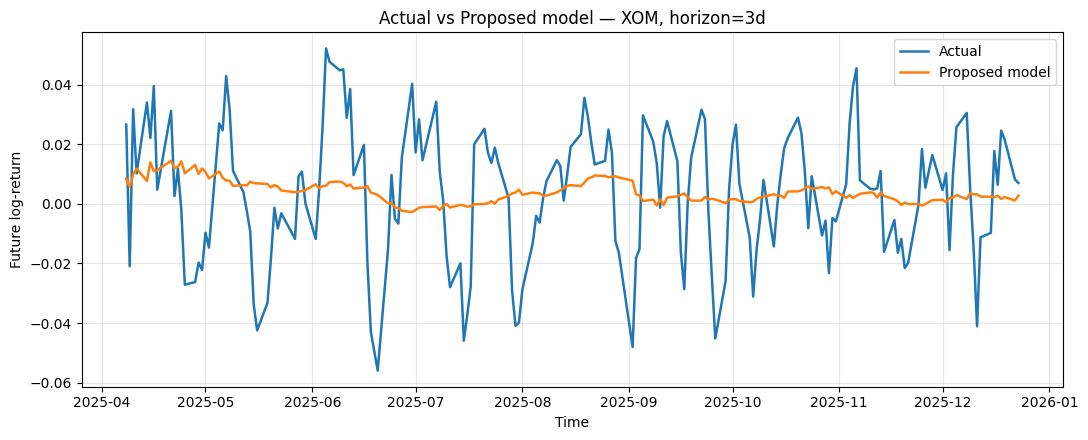

Saved: outputs/model_comparison/figures/actual_vs_proposed_XOM_3d.png


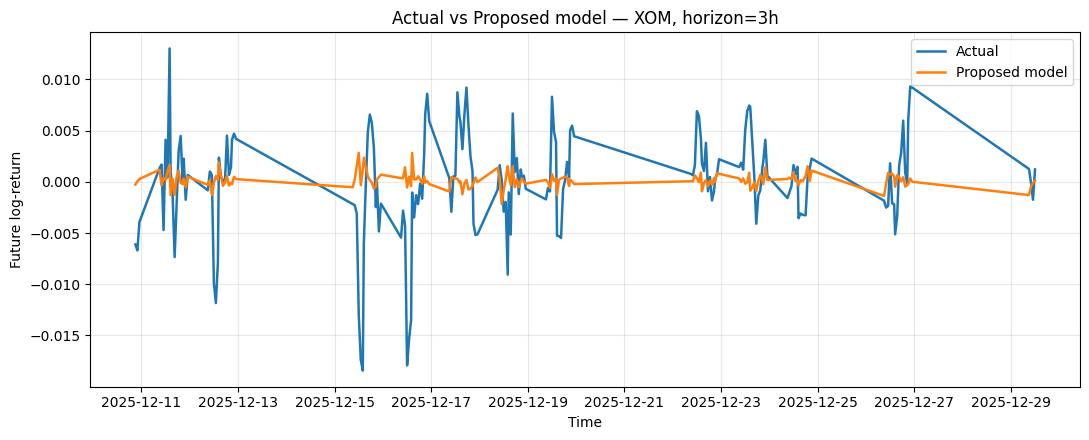

Saved: outputs/model_comparison/figures/actual_vs_proposed_XOM_3h.png


In [50]:
# =========================
# Main model configuration
# =========================
MAIN_MODEL = "News_TA_Ridge"
MAIN_MODEL_LABEL = "Proposed model"

# If needed, switch to another main model:
# MAIN_MODEL = "ARIMAX_News_TA"
# MAIN_MODEL_LABEL = "Proposed model"

MODEL_LABELS = {
    "Mean": "Mean",
    "ARIMA": "ARIMA",
    "TA_Ridge": "TA-only",
    "News_TA_Ridge": MAIN_MODEL_LABEL if MAIN_MODEL == "News_TA_Ridge" else "News+TA",
    "ARIMAX_News_TA": MAIN_MODEL_LABEL if MAIN_MODEL == "ARIMAX_News_TA" else "ARIMAX-X",
}

HORIZON_ORDER = {
    "1h": 0,
    "3h": 1,
    "1d": 2,
    "3d": 3,
}


def _ordered_horizons(values):
    vals = [str(v) for v in values]
    return sorted(vals, key=lambda x: HORIZON_ORDER.get(x, 999))


def _label_model(model):
    return MODEL_LABELS.get(model, model)


def plot_rmse_bars(metrics: pd.DataFrame):
    """
    One figure per ticker.
    X-axis: horizons (1h, 3h, 1d, 3d)
    Thin bars inside each horizon: models
    """
    if metrics is None or not len(metrics):
        return

    for ticker, g in metrics.groupby("ticker"):
        g = g.copy()

        # If there are duplicate rows for same horizon/model (e.g. different freq tags),
        # average them. Usually there should be one row per horizon-model-ticker.
        plot_df = (
            g.groupby(["horizon", "model"], as_index=False)["RMSE"]
            .mean()
        )

        horizons = _ordered_horizons(plot_df["horizon"].unique())
        models = list(plot_df["model"].dropna().unique())

        # Put the main model first
        if MAIN_MODEL in models:
            models = [MAIN_MODEL] + [m for m in models if m != MAIN_MODEL]
        else:
            models = sorted(models)

        pivot = plot_df.pivot(index="horizon", columns="model", values="RMSE")
        pivot = pivot.reindex(horizons)

        existing_models = [m for m in models if m in pivot.columns]
        pivot = pivot[existing_models]

        if pivot.empty:
            continue

        fig, ax = plt.subplots(figsize=(12, 5.2))

        x = np.arange(len(pivot.index))
        n_models = len(existing_models)
        width = min(0.78 / max(n_models, 1), 0.14)   # thin bars

        for i, model in enumerate(existing_models):
            offset = (i - (n_models - 1) / 2) * width
            vals = pivot[model].values
            label = _label_model(model)
            ax.bar(x + offset, vals, width=width, label=label)

        ax.set_xticks(x)
        ax.set_xticklabels(pivot.index)
        ax.set_xlabel("Forecast horizon")
        ax.set_ylabel("RMSE")
        ax.set_title(f"RMSE comparison across forecast horizons — {ticker}")
        ax.legend(title="Model", fontsize=9)
        ax.grid(axis="y", alpha=0.3)

        fig.tight_layout()
        out = FIG_DIR / f"rmse_all_horizons_{ticker}.png"
        fig.savefig(out, dpi=160, bbox_inches="tight")
        plt.show()
        print("Saved:", out)


def plot_actual_vs_main(predictions: pd.DataFrame):
    """
    One time-series figure per (ticker, horizon).
    Plot only Actual vs Proposed model.
    """
    if predictions is None or not len(predictions):
        return

    if MAIN_MODEL not in predictions.columns:
        print(f"Column {MAIN_MODEL!r} not found in predictions.")
        print("Available columns:", list(predictions.columns))
        return

    for (ticker, horizon), g in predictions.groupby(["ticker", "horizon"]):
        g = g.copy()
        g = g.dropna(subset=["y_true", MAIN_MODEL])

        if len(g) < 10:
            continue

        g["time"] = pd.to_datetime(g["time"])
        g = g.sort_values("time")

        fig, ax = plt.subplots(figsize=(11, 4.5))
        ax.plot(g["time"], g["y_true"], label="Actual", linewidth=1.8)
        ax.plot(g["time"], g[MAIN_MODEL], label=MAIN_MODEL_LABEL, linewidth=1.8)

        ax.set_title(f"Actual vs {MAIN_MODEL_LABEL} — {ticker}, horizon={horizon}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Future log-return")
        ax.legend()
        ax.grid(alpha=0.3)

        fig.tight_layout()
        out = FIG_DIR / f"actual_vs_proposed_{ticker}_{horizon}.png"
        fig.savefig(out, dpi=160, bbox_inches="tight")
        plt.show()
        print("Saved:", out)


plot_rmse_bars(pd.read_csv(OUT_DIR / "comparison_metrics.csv"))
# plot_rmse_bars(metrics)
plot_actual_vs_main(predictions)


## 8. Автоматический текстовый вывод для черновика раздела

После прогона можно использовать этот блок как основу для формулировок в главе 4. 
Точный академический текст лучше написать после того, как будут видны реальные таблицы и графики.


In [51]:

def build_short_conclusion(metrics: pd.DataFrame, dm: pd.DataFrame) -> str:
    if not len(metrics):
        return "Метрики не рассчитаны: отсутствуют входные данные или тестовые прогнозы."

    lines = []
    lines.append("Краткое резюме model comparison:")
    winners = metrics.sort_values("RMSE").groupby(["freq", "horizon", "ticker"], as_index=False).first()
    for _, r in winners.iterrows():
        lines.append(
            f"- {r['ticker']}, {r['freq']}, horizon={r['horizon']}: "
            f"минимальный RMSE у модели {r['model']} "
            f"(RMSE={r['RMSE']:.6f}, DirectionAcc={r['DirectionAcc']:.3f})."
        )

    if len(dm):
        sig = dm[(dm["p_value"] < 0.10) & (dm["mean_loss_diff_model_minus_ARIMA"] < 0)]
        if len(sig):
            lines.append("")
            lines.append("Модели, которые статистически лучше ARIMA на уровне 10% по DM-тесту:")
            for _, r in sig.iterrows():
                lines.append(
                    f"- {r['ticker']}, {r['freq']}, {r['horizon']}, {r['model']}, "
                    f"loss={r['loss']}, p={r['p_value']:.3f}."
                )
        else:
            lines.append("")
            lines.append("DM-тесты не выявили устойчивого статистически значимого превосходства над ARIMA на уровне 10%.")

    return "\n".join(lines)

summary_text = build_short_conclusion(metrics, dm)
print(summary_text)

with open(OUT_DIR / "auto_conclusion.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)
print("Saved:", OUT_DIR / "auto_conclusion.txt")


Краткое резюме model comparison:
- AAPL, daily, horizon=1d: минимальный RMSE у модели Mean (RMSE=0.015147, DirectionAcc=0.556).
- XOM, daily, horizon=1d: минимальный RMSE у модели Mean (RMSE=0.012490, DirectionAcc=0.564).
- AAPL, daily, horizon=3d: минимальный RMSE у модели ARIMAX_News_TA (RMSE=0.018378, DirectionAcc=0.822).
- XOM, daily, horizon=3d: минимальный RMSE у модели ARIMA (RMSE=0.016613, DirectionAcc=0.767).
- AAPL, intraday, horizon=1h: минимальный RMSE у модели TA_Ridge (RMSE=0.003223, DirectionAcc=0.478).
- XOM, intraday, horizon=1h: минимальный RMSE у модели Mean (RMSE=0.002933, DirectionAcc=0.528).
- AAPL, intraday, horizon=3h: минимальный RMSE у модели ARIMAX_News_TA (RMSE=0.004361, DirectionAcc=0.656).
- XOM, intraday, horizon=3h: минимальный RMSE у модели ARIMA (RMSE=0.003778, DirectionAcc=0.758).

Модели, которые статистически лучше ARIMA на уровне 10% по DM-тесту:
- AAPL, daily, 3d, ARIMAX_News_TA, loss=mse, p=0.032.
- AAPL, intraday, 3h, ARIMAX_News_TA, loss=mse, p

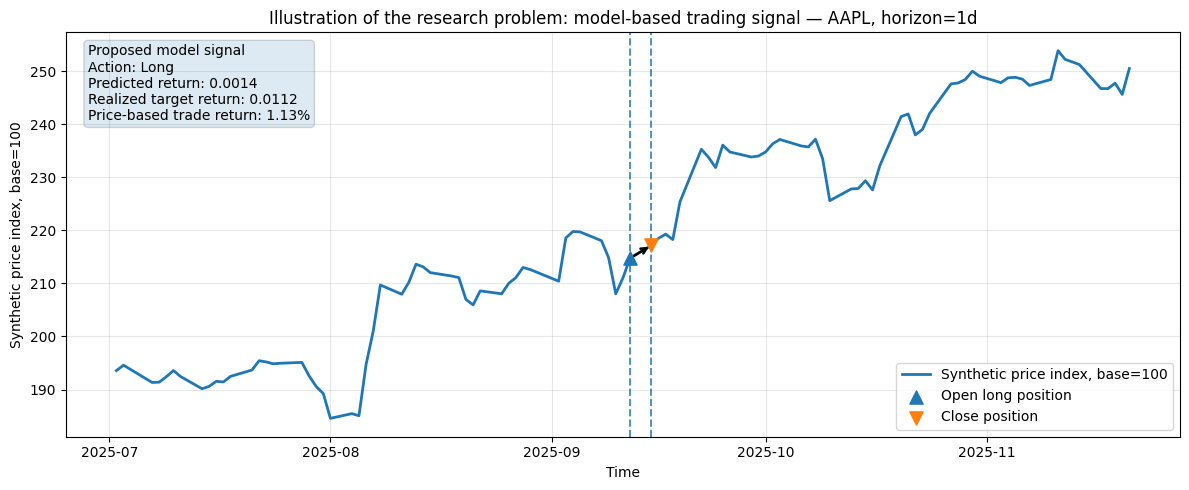

Saved: outputs/model_comparison/trading_figures/intro_trading_signal_AAPL_1d.png
Trade summary:
  ticker             : AAPL
  horizon            : 1d
  entry_time         : 2025-09-12 00:00:00
  exit_time          : 2025-09-15 00:00:00
  predicted_return   : 0.001442
  realized_target_ret: 0.011236
  price_trade_return : 1.13%


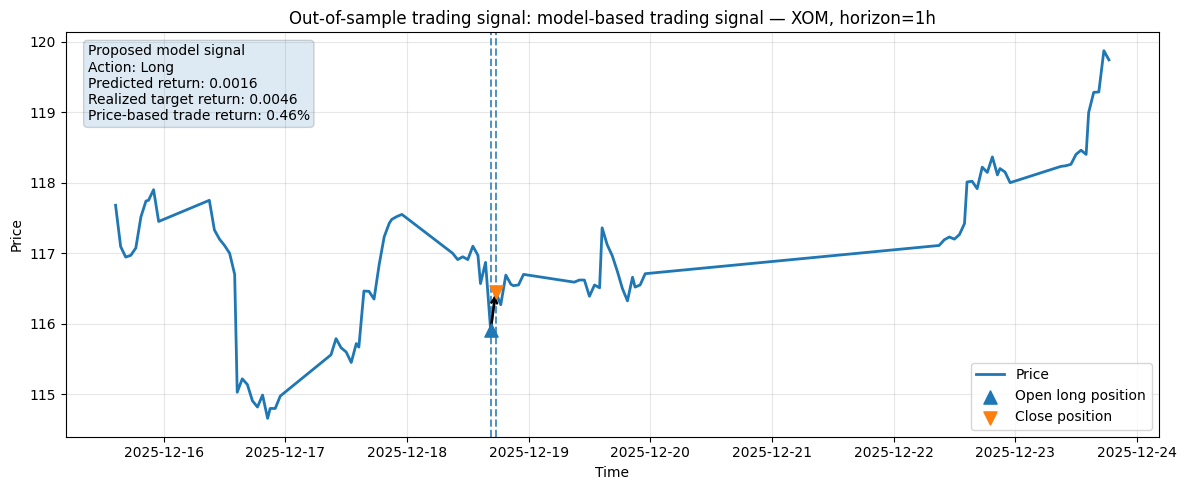

Saved: outputs/model_comparison/trading_figures/comparison_trading_signal_XOM_1h.png
Trade summary:
  ticker             : XOM
  horizon            : 1h
  entry_time         : 2025-12-18 16:30:00
  exit_time          : 2025-12-18 17:30:00
  predicted_return   : 0.001560
  realized_target_ret: 0.004605
  price_trade_return : 0.46%


In [52]:
# ============================================================
# Trading-style visualization for thesis:
# price series + model-based entry/exit annotations
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRADE_FIG_DIR = Path("outputs/model_comparison/trading_figures")
TRADE_FIG_DIR.mkdir(parents=True, exist_ok=True)

MAIN_MODEL = "News_TA_Ridge"
MAIN_MODEL_LABEL = "Proposed model"

# Можно поменять объект/горизонт для картинки во введение
INTRO_TICKER = "AAPL"
INTRO_HORIZON = "1d"

# Можно поменять объект/горизонт для картинки в раздел сравнения моделей
SECTION_TICKER = "XOM"
SECTION_HORIZON = "1h"


def _get_dataset_by_horizon(horizon):
    """
    Возвращает исходный датасет и название временной колонки
    по горизонту прогноза.
    """
    if str(horizon).endswith("h"):
        key = "intraday"
    else:
        key = "daily"

    if key not in datasets:
        raise ValueError(f"Dataset {key!r} not found. Available: {list(datasets.keys())}")

    df = datasets[key]["df"].copy()
    time_col = datasets[key]["time_col"]
    price_col = datasets[key].get("price_col", None)
    return df, time_col, price_col, key


def _choose_price_or_reconstruct(df, time_col, ticker, price_col=None):
    """
    Если цена есть — используем её.
    Если цены нет, восстанавливаем условный индекс цены из r_log.
    """
    df = df.copy()
    df = df[df["ticker"] == ticker].copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col)

    if price_col is not None and price_col in df.columns:
        df["plot_price"] = df[price_col].astype(float)
        price_label = "Price"
    elif "adj_close" in df.columns:
        df["plot_price"] = df["adj_close"].astype(float)
        price_label = "Adjusted close"
    elif "close" in df.columns:
        df["plot_price"] = df["close"].astype(float)
        price_label = "Close"
    elif "r_log" in df.columns:
        # Условная цена, нормированная к 100
        df["plot_price"] = 100 * np.exp(df["r_log"].fillna(0).cumsum())
        price_label = "Synthetic price index, base=100"
    elif "returns" in df.columns:
        df["plot_price"] = 100 * np.exp(df["returns"].fillna(0).cumsum())
        price_label = "Synthetic price index, base=100"
    else:
        raise ValueError("No price or return column found for visualization.")

    return df[[time_col, "ticker", "plot_price"]].copy(), price_label


def _select_trade_from_predictions(predictions, ticker, horizon, model_col=MAIN_MODEL):
    """
    Выбирает одну наглядную сделку:
    вход — в точке с сильным положительным прогнозом,
    выход — через заданный горизонт.
    """
    g = predictions[
        (predictions["ticker"] == ticker) &
        (predictions["horizon"].astype(str) == str(horizon))
    ].copy()

    if g.empty:
        raise ValueError(f"No predictions for ticker={ticker}, horizon={horizon}")

    if model_col not in g.columns:
        raise ValueError(f"Model column {model_col!r} not found in predictions.")

    g["time"] = pd.to_datetime(g["time"])
    g = g.dropna(subset=["y_true", model_col]).sort_values("time").reset_index(drop=True)

    if len(g) < 20:
        raise ValueError("Too few points for trading visualization.")

    # Берём положительный прогноз с достаточно большой амплитудой,
    # но не самый экстремальный край, чтобы график выглядел устойчиво.
    q = g[model_col].quantile(0.85)
    candidates = g[g[model_col] >= q].copy()

    if candidates.empty:
        candidates = g.sort_values(model_col, ascending=False).head(10)

    # Выбираем точку ближе к середине тестового окна
    mid_time = g["time"].iloc[len(g) // 2]
    candidates["distance_to_mid"] = (candidates["time"] - mid_time).abs()
    entry_row = candidates.sort_values("distance_to_mid").iloc[0]

    entry_idx = int(entry_row.name)

    if str(horizon).endswith("h"):
        h_steps = int(str(horizon).replace("h", ""))
    elif str(horizon).endswith("d"):
        h_steps = int(str(horizon).replace("d", ""))
    else:
        h_steps = 1

    exit_idx = min(entry_idx + h_steps, len(g) - 1)
    exit_row = g.iloc[exit_idx]

    trade = {
        "entry_time": entry_row["time"],
        "exit_time": exit_row["time"],
        "predicted_return": float(entry_row[model_col]),
        "realized_return": float(entry_row["y_true"]),
        "direction": "Long" if entry_row[model_col] >= 0 else "Short",
        "entry_idx": entry_idx,
        "exit_idx": exit_idx,
    }

    return g, trade


def plot_trade_case(
    predictions,
    ticker,
    horizon,
    output_name,
    title_prefix,
    window_points=90,
    model_col=MAIN_MODEL,
    model_label=MAIN_MODEL_LABEL,
):
    """
    Строит график цены с точками входа/выхода и подписью сделки.
    """
    raw_df, time_col, price_col, freq_key = _get_dataset_by_horizon(horizon)
    price_df, price_label = _choose_price_or_reconstruct(raw_df, time_col, ticker, price_col)

    pred_df, trade = _select_trade_from_predictions(
        predictions=predictions,
        ticker=ticker,
        horizon=horizon,
        model_col=model_col,
    )

    # Объединяем цену и прогнозы по времени
    price_df = price_df.rename(columns={time_col: "time"})
    pred_df = pred_df.sort_values("time")

    merged = pd.merge_asof(
        pred_df.sort_values("time"),
        price_df.sort_values("time"),
        on="time",
        by="ticker",
        direction="nearest"
    )

    merged = merged.dropna(subset=["plot_price"]).reset_index(drop=True)

    # Находим индекс входа уже в merged
    entry_time = trade["entry_time"]
    entry_pos = int((merged["time"] - entry_time).abs().idxmin())

    start = max(entry_pos - window_points // 2, 0)
    end = min(entry_pos + window_points // 2, len(merged) - 1)
    w = merged.iloc[start:end+1].copy()

    # Точки входа и выхода внутри окна
    entry_plot = w.iloc[(w["time"] - trade["entry_time"]).abs().argmin()]
    exit_plot = w.iloc[(w["time"] - trade["exit_time"]).abs().argmin()]

    entry_price = float(entry_plot["plot_price"])
    exit_price = float(exit_plot["plot_price"])

    if trade["direction"] == "Long":
        trade_return_price = exit_price / entry_price - 1
    else:
        trade_return_price = entry_price / exit_price - 1

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(w["time"], w["plot_price"], linewidth=2.0, label=price_label)

    # Entry / Exit vertical lines
    ax.axvline(trade["entry_time"], linestyle="--", linewidth=1.4, alpha=0.8)
    ax.axvline(trade["exit_time"], linestyle="--", linewidth=1.4, alpha=0.8)

    # Markers
    ax.scatter(
        [entry_plot["time"]],
        [entry_price],
        s=90,
        marker="^",
        label="Open long position",
        zorder=5,
    )

    ax.scatter(
        [exit_plot["time"]],
        [exit_price],
        s=90,
        marker="v",
        label="Close position",
        zorder=5,
    )

    # Arrow from entry to exit
    ax.annotate(
        "",
        xy=(exit_plot["time"], exit_price),
        xytext=(entry_plot["time"], entry_price),
        arrowprops=dict(arrowstyle="->", lw=1.8),
    )

    annotation = (
        f"{model_label} signal\n"
        f"Action: {trade['direction']}\n"
        f"Predicted return: {trade['predicted_return']:.4f}\n"
        f"Realized target return: {trade['realized_return']:.4f}\n"
        f"Price-based trade return: {trade_return_price:.2%}"
    )

    ax.text(
        0.02,
        0.97,
        annotation,
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round", alpha=0.15),
        fontsize=10,
    )

    ax.set_title(f"{title_prefix}: model-based trading signal — {ticker}, horizon={horizon}")
    ax.set_xlabel("Time")
    ax.set_ylabel(price_label)
    ax.legend(loc="best")
    ax.grid(alpha=0.3)

    fig.tight_layout()

    out = TRADE_FIG_DIR / output_name
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()

    print("Saved:", out)
    print("Trade summary:")
    print(f"  ticker             : {ticker}")
    print(f"  horizon            : {horizon}")
    print(f"  entry_time         : {trade['entry_time']}")
    print(f"  exit_time          : {trade['exit_time']}")
    print(f"  predicted_return   : {trade['predicted_return']:.6f}")
    print(f"  realized_target_ret: {trade['realized_return']:.6f}")
    print(f"  price_trade_return : {trade_return_price:.2%}")

    return out


# ============================================================
# 1) Figure for Introduction
# ============================================================

intro_fig = plot_trade_case(
    predictions=predictions,
    ticker=INTRO_TICKER,
    horizon=INTRO_HORIZON,
    output_name=f"intro_trading_signal_{INTRO_TICKER}_{INTRO_HORIZON}.png",
    title_prefix="Illustration of the research problem",
    window_points=100,
)

# ============================================================
# 2) Figure for model comparison section
# ============================================================

section_fig = plot_trade_case(
    predictions=predictions,
    ticker=SECTION_TICKER,
    horizon=SECTION_HORIZON,
    output_name=f"comparison_trading_signal_{SECTION_TICKER}_{SECTION_HORIZON}.png",
    title_prefix="Out-of-sample trading signal",
    window_points=100,
)